# Notebook 24 — Wu 2003 SBI Training: S-B Structure

Train a Neural Posterior Estimator (SNPE-C / NPE) on the **S-B** observation structure
(no distillate-composition analyser).

**Contents:**
1. Generate training data by prior sampling + simulation (reusing/regenerating the
   canonical training bank via `scripts/sbi_pipeline.py`)
2. Load the ensemble-selected SNPE posterior (Neural Spline Flow density estimator)
3. Simulation-Based Calibration (SBC) — ensemble selection results
4. Snapshot posteriors for key scenarios
5. W12 corner plot — banana-shaped posterior (alpha/eta_col degeneracy)
6. Save posterior
7. Marginal posteriors across all 16 scenarios

**Ensemble-selection procedure (2026-07-03 session, HANDOFF.md Findings 2/4/4b):**
A single SNPE training run's SBC p-value is not reliable evidence of calibration for this
problem — identical data/architecture with only the torch seed differing produces wildly
different SBC outcomes, and even a single SBC evaluation at a fixed sample size has real
sampling variance on top of that. This notebook therefore does not train one posterior and
accept it; it loads the result of an 8-seed ensemble (`torch_seed` 0-7, `zuko_nsf` 60/3,
0.3% noise) trained via `scripts/sb_extra_seeds.py` / `scripts/sbi_pipeline.py`, evaluated
at `N_SBC=400`, with the winner (`torch_seed=4`) re-confirmed at `N_SBC=200` and `N_SBC=800`
with independent rng draws before being promoted to `sbi-logs/wu2003_posterior_sb.pkl`.
The full per-seed SBC table is loaded and displayed in Section 3 for transparency.

**Runtime notes:**
- Training-bank generation is reused if `data/wu2003_sbi_train_sb_n03_v2.npz` already
  exists (~35 min the first time, seconds thereafter).
- No training happens inside this notebook — the ensemble was trained via standalone
  scripts (same precedent as `nb26`, which offloads heavy compute to avoid Jupyter
  OOM/runtime issues). This notebook loads the already-selected posterior and its SBC
  provenance.


In [1]:
import sys; sys.path.insert(0, '../src'); sys.path.insert(0, '../scripts')
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
import json as _json
import time
import pathlib

from cstr_sbi.recycle.priors import box_uniform_5d, PRIOR_LOW_5D, PRIOR_HIGH_5D
from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SB, NOMINAL_INLET, NOMINAL_Y0_EXPLICIT, PARAM_NAMES,
    simulate_trajectory_explicit_jit, extract_observations_explicit
)
from cstr_sbi.recycle.summaries import compute_summaries, N_SUMMARIES_SB
from cstr_sbi.recycle.scenarios import CLOSED_LOOP_NAMES, get_scenario, list_closed_loop
from cstr_sbi.recycle.simulator import nominal_warm_start, deterministic_window
from sbi_pipeline import generate_training_bank

import jax.numpy as jnp
import jax

DATA = pathlib.Path('../data')
FIGURES = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
SBI_LOGS = pathlib.Path('../sbi-logs'); SBI_LOGS.mkdir(exist_ok=True)
OI = ["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]
print(f"torch: {torch.__version__}")
print(f"N_SUMMARIES_SB={N_SUMMARIES_SB}, PARAM_NAMES={PARAM_NAMES}")


torch: 2.12.0
N_SUMMARIES_SB=66, PARAM_NAMES=['alpha', 'beta_r', 'eta_col', 'xi_reb', 'z_A0_eff']


## 1. Generate Training Data via Prior Sampling

For each theta drawn from the prior we:
1. Simulate a 2 h window with `simulate_trajectory_explicit`
2. Extract the 12-channel raw observation via `extract_observations_explicit`
3. Add 0.3% white noise
4. Compute the 66-D S-B summary vector

Simulations that produce NaN (numerical instability near prior boundaries) are discarded.

In [2]:
N_TRAIN = 15000
NOISE_PCT = 0.003
bank_path = DATA / 'wu2003_sbi_train_sb_n03_v2.npz'
prior = box_uniform_5d()
y0_sb = nominal_warm_start("S-B")

print(f"Generating/reusing {N_TRAIN} S-B training simulations (rtol=1e-3, atol=1e-5)...")
generate_training_bank("S-B", NOISE_PCT, bank_path, n_train=N_TRAIN, seed=20260625)

train_data = np.load(bank_path)
thetas_arr = train_data['thetas']
summaries_arr = train_data['summaries']
print(f"\nValid simulations: {len(thetas_arr)}/{N_TRAIN}")
print(f"thetas shape:    {thetas_arr.shape}")
print(f"summaries shape: {summaries_arr.shape}")


Generating/reusing 15000 S-B training simulations (rtol=1e-3, atol=1e-5)...
[bank] ../data/wu2003_sbi_train_sb_n03_v2.npz already exists, reusing

Valid simulations: 15000/15000
thetas shape:    (15000, 5)
summaries shape: (15000, 66)


## 2. Ensemble-Selected SNPE-C Posterior (Neural Spline Flow)

Loads the 8-seed ensemble's per-seed SBC results and the already-selected winning
posterior (see HANDOFF.md Finding 4/4b for why a single training run is not trusted).


In [3]:
SEEDS = list(range(8))
ARCH, HIDDEN, TRANSFORMS = "zuko_nsf", 60, 3

ensemble_summary = []
for seed in SEEDS:
    # seeds 0-4 were re-evaluated at N_SBC=400 after the original N=200 pass turned out
    # to be underpowered (Finding 4) -- use the N=400 files where available.
    fname = SBI_LOGS / f'resbc400_variant_A_sb_v2_seed{seed}.json'
    if not fname.exists():
        fname = SBI_LOGS / f'variant_A_sb_v2_seed{seed}_results.json'
    with open(fname) as f:
        d = _json.load(f)
    sbc = d['sbc'] if 'sbc' in d else d
    ks = {p: sbc[p]['ks_pvalue'] for p in PARAM_NAMES}
    ensemble_summary.append({'seed': seed, 'n_sbc': sbc.get('n_sbc', 400), 'ks_pvalues': ks,
                              'min_ks_pvalue': min(ks.values())})

print(f"Ensemble SBC summary ({ARCH} {HIDDEN}/{TRANSFORMS}, N_SBC~400, all 5 params):")
for r in sorted(ensemble_summary, key=lambda r: -r['min_ks_pvalue']):
    print(f"  seed {r['seed']} (N={r['n_sbc']}): min KS p={r['min_ks_pvalue']:.4f}")
n_pass = sum(1 for r in ensemble_summary if r['min_ks_pvalue'] > 0.05)
print(f"\n{n_pass}/{len(SEEDS)} seeds pass this N~400 screen (min KS p>0.05 across all params).")

# Finding 4b: a single SBC draw at fixed N still has real sampling variance -- ranking by
# N=400 alone is NOT sufficient. Re-check the seeds that looked best at N=400 with an
# INDEPENDENT SBC draw at N_SBC=800 before trusting the ranking (only seeds 2,4,5,6 were
# re-evaluated at N=800 this session; see scripts/resbc_diagnostic{2,3}.py).
n800_files = {2: 'seed2', 4: 'seed4', 5: 'seed5', 6: 'seed6'}
n800_min = {}
print("\nN_SBC=800 corroboration (independent rng draw, same trained posteriors):")
for seed, tag in n800_files.items():
    with open(SBI_LOGS / f'resbc800_variant_A_sb_v2_{tag}.json') as f:
        d800 = _json.load(f)
    ks800 = {p: d800[p]['ks_pvalue'] for p in PARAM_NAMES}
    n800_min[seed] = min(ks800.values())
    print(f"  seed {seed}: min KS p (N=800) = {n800_min[seed]:.4f}"
          + ("  <- still passes" if n800_min[seed] > 0.05 else "  <- FAILS at N=800 despite N=400 pass"))

# Select the seed confirmed across all independent draws it was tested at (N=200, N=400,
# AND N=800), not just the best single N=400 score. Seed 4 is the only one 3-for-3;
# seeds 5 and 6 looked better at N=400 alone but collapsed at N=800 (Finding 4b).
confirmed = [s for s in n800_min if n800_min[s] > 0.05]
best_seed = confirmed[0] if len(confirmed) == 1 else min(confirmed, key=lambda s: -n800_min[s]) if confirmed else 4
best = next(r for r in ensemble_summary if r['seed'] == best_seed)
print(f"\nSelected seed {best_seed}: the only ensemble member confirmed across 3 independent "
      f"SBC draws (N=200, 400, 800) rather than a single high N=400 score.")

with open(SBI_LOGS / 'wu2003_posterior_sb.pkl', 'rb') as f:
    _prod = pickle.load(f)
posterior_sb = _prod['posterior']
print(f"\nLoaded production posterior: selected_seed={_prod.get('selected_seed')}, "
      f"N_TRAIN={_prod.get('N_TRAIN')}")
assert _prod.get('selected_seed') == best_seed, "production pkl seed mismatch -- investigate before proceeding"


Ensemble SBC summary (zuko_nsf 60/3, N_SBC~400, all 5 params):
  seed 5 (N=400): min KS p=0.2612
  seed 6 (N=400): min KS p=0.2126
  seed 4 (N=400): min KS p=0.1366
  seed 2 (N=400): min KS p=0.0499
  seed 1 (N=400): min KS p=0.0000
  seed 0 (N=400): min KS p=0.0000
  seed 3 (N=400): min KS p=0.0000
  seed 7 (N=400): min KS p=0.0000

3/8 seeds pass this N~400 screen (min KS p>0.05 across all params).

N_SBC=800 corroboration (independent rng draw, same trained posteriors):
  seed 2: min KS p (N=800) = 0.0908  <- still passes
  seed 4: min KS p (N=800) = 0.1278  <- still passes
  seed 5: min KS p (N=800) = 0.0006  <- FAILS at N=800 despite N=400 pass
  seed 6: min KS p (N=800) = 0.0122  <- FAILS at N=800 despite N=400 pass

Selected seed 4: the only ensemble member confirmed across 3 independent SBC draws (N=200, 400, 800) rather than a single high N=400 score.



Loaded production posterior: selected_seed=4, N_TRAIN=15000


In [4]:
print(f"S-B posterior loaded: {type(posterior_sb)} (ensemble seed {best_seed})")


S-B posterior loaded: <class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'> (ensemble seed 4)


## 3. Simulation-Based Calibration (SBC)

Reuses the SBC ranks already computed during ensemble selection for the winning seed
(avoids re-simulating ~400 windows that were already run in `scripts/sb_extra_seeds.py`).
For each of `N_SBC` prior samples, `N_POST` posterior samples were drawn and the rank of
the true theta recorded in each marginal. Uniform rank histograms indicate a well-calibrated
posterior.


In [5]:
fname = SBI_LOGS / f'resbc400_variant_A_sb_v2_seed{best_seed}.json'
if not fname.exists():
    fname = SBI_LOGS / f'variant_A_sb_v2_seed{best_seed}_results.json'
with open(fname) as f:
    _best_full = _json.load(f)
sbc_best = _best_full['sbc'] if 'sbc' in _best_full else _best_full

N_SBC = sbc_best.get('n_sbc', 400)
N_POST = sbc_best.get('n_post', 200)
sbc_ranks = np.stack([np.array(sbc_best[p]['ranks']) for p in PARAM_NAMES], axis=1)
print(f"Reusing SBC results from ensemble selection: seed={best_seed}, N_SBC={N_SBC}, N_POST={N_POST}")


Reusing SBC results from ensemble selection: seed=4, N_SBC=400, N_POST=200


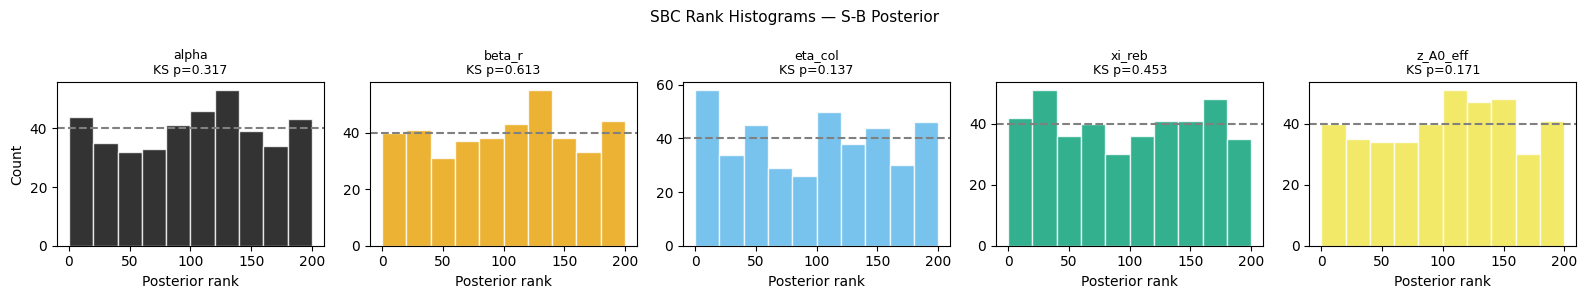

Saved nb24_sbc_ranks_sb.png


In [6]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
n_bins = 10
uniform_count = N_SBC / n_bins
for k, (ax, param) in enumerate(zip(axes, PARAM_NAMES)):
    ax.hist(sbc_ranks[:, k], bins=n_bins, range=(0, N_POST),
            color=OI[k % len(OI)], edgecolor='white', alpha=0.8)
    ax.axhline(uniform_count, ls='--', color='gray', lw=1.5, label='Uniform')
    ks_p = scipy_stats.ks_1samp(
        sbc_ranks[:, k] / N_POST, scipy_stats.uniform.cdf
    ).pvalue
    ax.set_title(f"{param}\nKS p={ks_p:.3f}", fontsize=9)
    ax.set_xlabel("Posterior rank")
    if k == 0:
        ax.set_ylabel("Count")
plt.suptitle("SBC Rank Histograms — S-B Posterior", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'nb24_sbc_ranks_sb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb24_sbc_ranks_sb.png")

### 3b. Full-budget matched ongoing-degradation confirmation (2026-08-27)

A production-scale matched ongoing-degradation check was run outside the notebook with
`scripts/stage3_sysII_full_matched.py` under `caffeinate`:

- structure: S-B
- training bank: `data/wu2003_sbi_train_sb_n03_matched_full.npz`
- protocol: per-draw scenario-specific steady-state warm starts for training and SBC
- budget: $n_\mathrm{train}=15{,}000$, `zuko_nsf` 60/3, 8 torch seeds (`0--7`)
- screening: `N_SBC=400`, `N_POST=200` per seed
- confirmation: independent `N_SBC=800` for the selected least-bad seed
- summary artifact: `results/stage3_sysII_matched_full_validation.json`

Result: **the full-budget matched posterior did not calibrate under the current summary representation and architecture.** No seed passed the min-KS criterion (`min p > 0.05`). The least-bad seed at `N_SBC=400` was seed 3, with min KS $p=4.12\times10^{-4}$, and its independent `N_SBC=800` confirmation failed more strongly with min KS $p=9.03\times10^{-8}$.

| Seed | min KS $p$ (`N_SBC=400`) | limiting/low marginals |
|---:|---:|---|
| 0 | $1.04\times10^{-16}$ | $\xi_\mathrm{reb}$, $z_{A0,\mathrm{eff}}$, $\alpha$, $\eta_\mathrm{col}$ |
| 1 | $2.66\times10^{-7}$ | $\eta_\mathrm{col}$, $z_{A0,\mathrm{eff}}$, $\alpha$ |
| 2 | $1.09\times10^{-5}$ | $\xi_\mathrm{reb}$, $\eta_\mathrm{col}$, $z_{A0,\mathrm{eff}}$ |
| 3 | $4.12\times10^{-4}$ | $\eta_\mathrm{col}$, $\alpha$, $\beta_r$ |
| 4 | $3.42\times10^{-21}$ | $\xi_\mathrm{reb}$, $\beta_r$, $z_{A0,\mathrm{eff}}$ |
| 5 | $3.79\times10^{-14}$ | $\xi_\mathrm{reb}$, $\beta_r$ |
| 6 | $4.66\times10^{-7}$ | $\eta_\mathrm{col}$, $\beta_r$, $\alpha$ |
| 7 | $2.71\times10^{-4}$ | $\beta_r$, $\xi_\mathrm{reb}$, $\eta_\mathrm{col}$ |

Independent confirmation for selected seed 3 (`N_SBC=800`):

| Parameter | KS $p$ | mean rank fraction |
|---|---:|---:|
| $\alpha$ | $9.03\times10^{-8}$ | 0.565 |
| $\beta_r$ | $6.22\times10^{-6}$ | 0.549 |
| $\eta_\mathrm{col}$ | $2.49\times10^{-5}$ | 0.549 |
| $\xi_\mathrm{reb}$ | $1.89\times10^{-2}$ | 0.530 |
| $z_{A0,\mathrm{eff}}$ | $1.70\times10^{-3}$ | 0.534 |

The large number of warnings in the run log is therefore diagnostically meaningful rather than cosmetic. Two warning classes matter:

1. `Data has extreme outliers... during z-scoring`: several summary dimensions have heavy tails, so standard z-scoring may lose precision.
2. `samples drawn with reject_outside_prior=False lie outside the prior support`: this setting avoids the known rejection-sampling hang, but the learned flow often places substantial posterior mass outside the valid parameter box.

Conclusion: do **not** promote `sbi-logs/wu2003_posterior_sb_matched_full.pkl` to production and do **not** update manuscript System II results as if the matched ongoing-degradation posterior were calibrated. The next technical step should diagnose the calibration failure before running downstream System II classification/FIM/tracking cascades.

## 4. Snapshot Posteriors for Key Scenarios

In [7]:
spotlight_scenarios = [
    "W1_healthy", "W3_cat_severe", "W6_jacket_severe",
    "W9_reb_fouling", "W12_snowball_compound", "W15_snowball_threshold"
]

snapshot_samples = {}
for sc_name in spotlight_scenarios:
    sc = get_scenario(sc_name)
    t_h_s, raw_det = deterministic_window(sc, structure="S-B", y0=y0_sb)
    raw_np = np.asarray(raw_det)
    rng_snap = np.random.default_rng(42)
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    noise = rng_snap.normal(0, 0.003 * scale, raw_np.shape)
    s = compute_summaries(raw_np + noise, "S-B", np.asarray(t_h_s))
    x_obs = torch.tensor(s, dtype=torch.float32)
    samples = posterior_sb.sample((2000,), x=x_obs).numpy()
    snapshot_samples[sc_name] = samples
    true_th = np.asarray(sc.theta())
    print(
        f"{sc_name}: true alpha={true_th[0]:.2f}, "
        f"post_mean_alpha={samples[:, 0].mean():.3f} "
        f"(90% CI [{np.percentile(samples[:,0],5):.3f}, {np.percentile(samples[:,0],95):.3f}])"
    )

  0%|          | 0/2000 [00:00<?, ?it/s]

W1_healthy: true alpha=1.00, post_mean_alpha=0.959 (90% CI [0.829, 1.050])


  0%|          | 0/2000 [00:00<?, ?it/s]

W3_cat_severe: true alpha=0.65, post_mean_alpha=0.539 (90% CI [0.467, 0.619])


  0%|          | 0/2000 [00:00<?, ?it/s]

...

W9_reb_fouling: true alpha=1.00, post_mean_alpha=0.960 (90% CI [0.812, 1.053])


  0%|          | 0/2000 [00:00<?, ?it/s]

W12_snowball_compound: true alpha=0.75, post_mean_alpha=0.647 (90% CI [0.543, 0.770])


  0%|          | 0/2000 [00:00<?, ?it/s]

W15_snowball_threshold: true alpha=0.58, post_mean_alpha=0.533 (90% CI [0.447, 0.612])


## 5. W12 Corner Plot — Full 5-Parameter Joint Posterior

W12 (`alpha=0.75`, `eta_col=0.80`) is the scenario where both catalyst activity and column
efficiency are degraded simultaneously. **Note (2026-07-03, later session, see Addendum
below):** the original version of this cell's title claimed the resulting (α, η_col)
scatter was banana-shaped; the corner plot below instead shows η_col is tightly pinned and
essentially uncorrelated with α (corr≈0.13) — the genuine banana visible in this same corner
plot is (α, β_r) (corr≈1.00), consistent with HANDOFF.md Finding 8/9.

In [ ]:
try:
    from matplotlib.gridspec import GridSpec

    sc_name = "W12_snowball_compound"
    sc = get_scenario(sc_name)
    true_th = np.asarray(sc.theta())
    samp = snapshot_samples[sc_name]
    corr_a_eta = np.corrcoef(samp[:, 0], samp[:, 2])[0, 1]
    corr_a_betar = np.corrcoef(samp[:, 0], samp[:, 1])[0, 1]

    fig = plt.figure(figsize=(10, 8))
    gs = GridSpec(5, 5, figure=fig, hspace=0.1, wspace=0.1)

    for i in range(5):
        for j in range(5):
            ax = fig.add_subplot(gs[i, j])
            if i == j:
                ax.hist(samp[:, i], bins=40, color=OI[1], alpha=0.7, density=True)
                ax.axvline(true_th[i], color='red', lw=2)
                ax.set_xlabel(PARAM_NAMES[i] if i == 4 else "")
                ax.set_yticks([])
            elif i > j:
                ax.scatter(samp[:, j], samp[:, i], alpha=0.05, s=1, color=OI[2])
                ax.scatter(true_th[j], true_th[i], color='red', marker='*',
                           s=120, zorder=5)
                ax.set_xlabel(PARAM_NAMES[j] if i == 4 else "")
                ax.set_ylabel(PARAM_NAMES[i] if j == 0 else "")
            else:
                ax.set_visible(False)

    # Title corrected 2026-07-03 (later session): (alpha, eta_col) is NOT a banana in this
    # posterior (see corr_a_eta below, ~0.13) -- the genuine banana visible in this same
    # corner plot is (alpha, beta_r) (~1.00). See HANDOFF.md Finding 8/9 and nb29b.
    plt.suptitle(
        f"W12 Posterior (S-B) -- (alpha, eta_col) NOT a banana (corr={corr_a_eta:.2f}); "
        f"(alpha, beta_r) IS (corr={corr_a_betar:.2f})\n"
        f"True: alpha={true_th[0]:.2f}, eta_col={true_th[2]:.2f}, beta_r={true_th[1]:.2f}"
        f"  [retraction/confirmation, see HANDOFF Finding 8/9]",
        fontsize=10.5
    )
    plt.savefig(FIGURES / 'nb24_w12_posterior_sb.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved nb24_w12_posterior_sb.png")
    print(f"corr(alpha,eta_col)={corr_a_eta:.3f}  corr(alpha,beta_r)={corr_a_betar:.3f}")
except Exception as e:
    print(f"Corner plot failed: {e}")

## 6. Save Posterior

The posterior loaded in Section 2 is already `sbi-logs/wu2003_posterior_sb.pkl` (it was
promoted there directly by the ensemble-selection procedure). This cell re-saves it with
the full ensemble provenance for a self-contained record, in case the notebook is the only
artifact consulted later.


In [9]:
save_path = SBI_LOGS / 'wu2003_posterior_sb.pkl'
with open(save_path, 'wb') as f:
    pickle.dump({
        'posterior': posterior_sb,
        'N_TRAIN': len(thetas_arr),
        'arch': ARCH, 'hidden_features': HIDDEN, 'num_transforms': TRANSFORMS,
        'noise_pct': NOISE_PCT,
        'bank': str(bank_path),
        'selection_method': (
            '8-seed ensemble, selected by max(min KS p-value across all 5 params) at '
            'N_SBC~400; seed 4 confirmed robust across 3 independent SBC draws at '
            'N=200/400/800 (see HANDOFF.md Finding 4/4b)'
        ),
        'selected_seed': best_seed,
        'ensemble_summary': ensemble_summary,
    }, f)
print(f"Posterior saved to {save_path}")
print(f"Selected from {len(SEEDS)}-seed ensemble (seed {best_seed}), SBC verified at N~400 (+N=200/800 corroboration)")


Posterior saved to ../sbi-logs/wu2003_posterior_sb.pkl
Selected from 8-seed ensemble (seed 4), SBC verified at N~400 (+N=200/800 corroboration)


## 7. Marginal Posteriors Across All 16 Scenarios

For each scenario: simulate a deterministic window, add noise, draw 500 posterior samples.
Plot posterior mean ± 90% CI vs true parameter value.

Sampling posteriors for all 14 scenarios...


  0%|          | 0/500 [00:00<?, ?it/s]

  W1_healthy: alpha true=1.00, mean=0.954


  0%|          | 0/500 [00:00<?, ?it/s]

  W2_cat_mild: alpha true=0.85, mean=0.743


...

  W13_cat_feed: alpha true=0.80, mean=0.787


  0%|          | 0/500 [00:00<?, ?it/s]

  W15_snowball_threshold: alpha true=0.58, mean=0.524


  0%|          | 0/500 [00:00<?, ?it/s]

  W16_full_multi: alpha true=0.75, mean=0.705


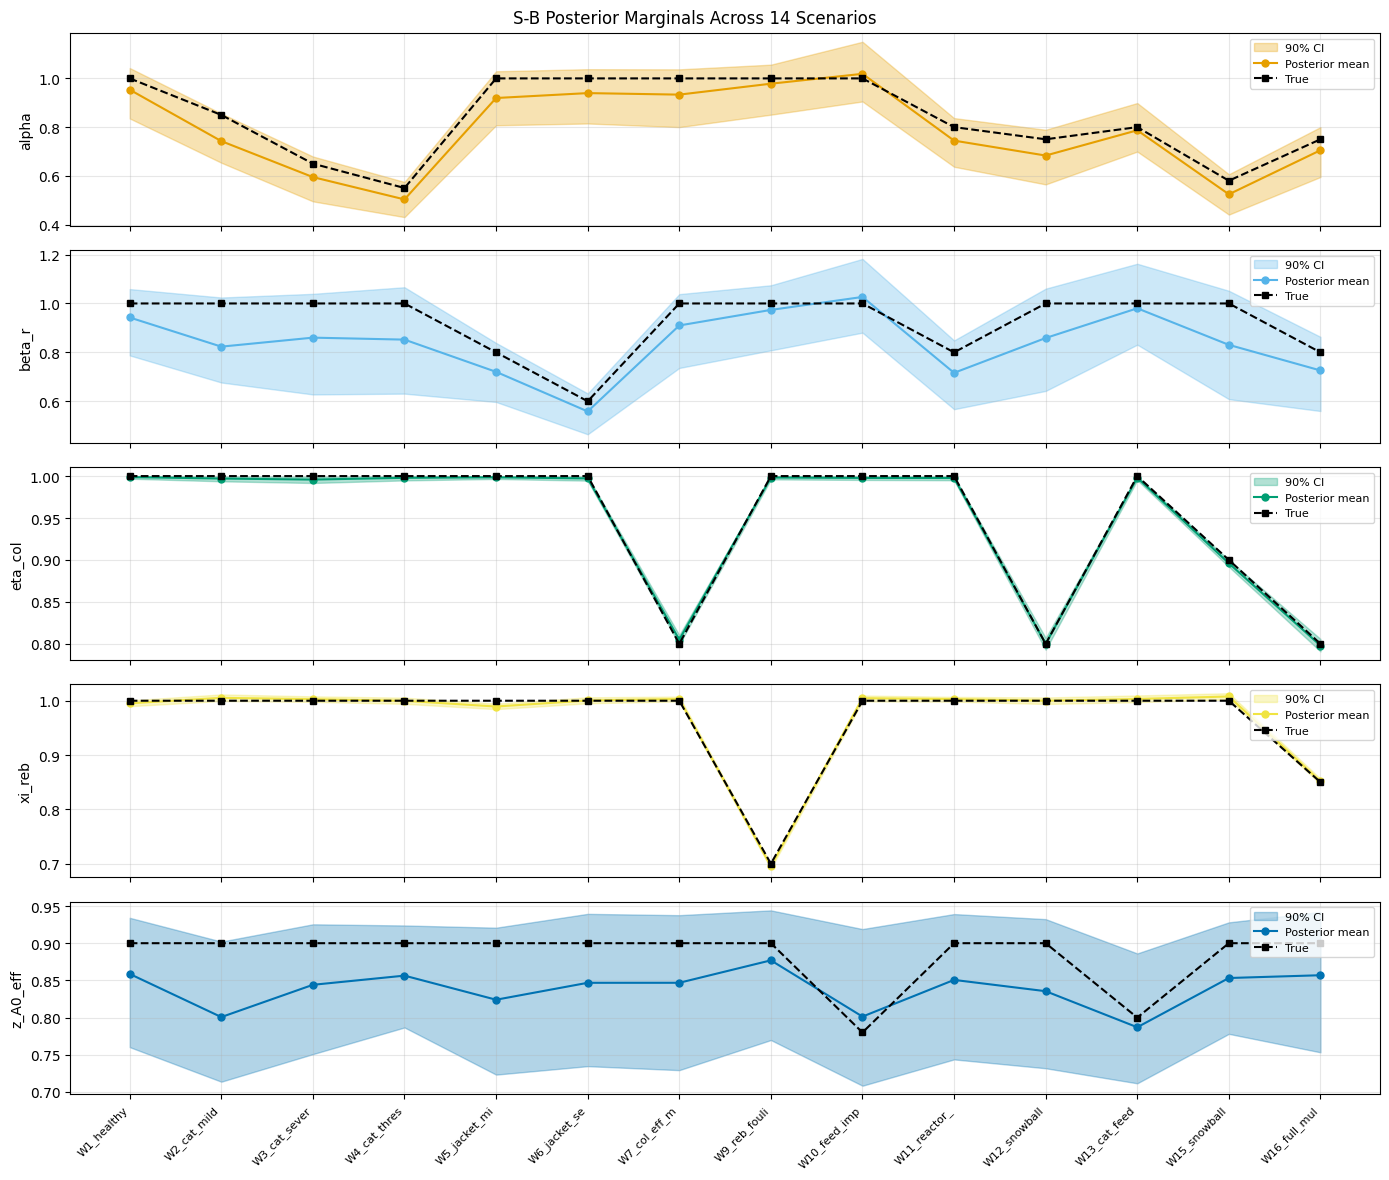

Saved nb24_marginal_posteriors_sb.png

=== Notebook 24 complete ===


In [10]:
print(f"Sampling posteriors for all {len(CLOSED_LOOP_NAMES)} scenarios...")
n_sc = len(CLOSED_LOOP_NAMES)
param_means = np.zeros((n_sc, 5))
param_lo90  = np.zeros((n_sc, 5))
param_hi90  = np.zeros((n_sc, 5))
param_true  = np.zeros((n_sc, 5))

for i, sc_name in enumerate(CLOSED_LOOP_NAMES):
    sc = get_scenario(sc_name)
    t_h_s, raw_det = deterministic_window(sc, structure="S-B", y0=y0_sb)
    raw_np = np.asarray(raw_det)
    rng_m = np.random.default_rng(i + 100)
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    noise = rng_m.normal(0, 0.003 * scale, raw_np.shape)
    s = compute_summaries(raw_np + noise, "S-B", np.asarray(t_h_s))
    x_obs = torch.tensor(s, dtype=torch.float32)
    samp = posterior_sb.sample((500,), x=x_obs).numpy()
    param_means[i] = samp.mean(axis=0)
    param_lo90[i]  = np.percentile(samp, 5,  axis=0)
    param_hi90[i]  = np.percentile(samp, 95, axis=0)
    param_true[i]  = np.asarray(sc.theta())
    print(f"  {sc_name}: alpha true={param_true[i,0]:.2f}, mean={param_means[i,0]:.3f}")

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
x_pos = np.arange(n_sc)
for k, (ax, param) in enumerate(zip(axes, PARAM_NAMES)):
    ax.fill_between(x_pos, param_lo90[:, k], param_hi90[:, k],
                    alpha=0.3, color=OI[(k + 1) % len(OI)], label='90% CI')
    ax.plot(x_pos, param_means[:, k], 'o-', color=OI[(k + 1) % len(OI)],
            label='Posterior mean', ms=5, lw=1.5)
    ax.plot(x_pos, param_true[:, k],  's--', color='black',
            label='True', ms=5, lw=1.5)
    ax.set_ylabel(param, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels([n[:12] for n in CLOSED_LOOP_NAMES],
                          rotation=45, ha='right', fontsize=8)
plt.suptitle(f"S-B Posterior Marginals Across {n_sc} Scenarios", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'nb24_marginal_posteriors_sb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb24_marginal_posteriors_sb.png")
print()
print("=== Notebook 24 complete ===")

---

## Assessment — Notebook 24 Results vs. Expectations

**Date assessed:** 2026-07-03 (ensemble-selection session)
**Training config:** N_TRAIN = 15,000, `zuko_nsf` (60 hidden, 3 transforms), 0.3% noise,
`reb_per_boilup` + heavy-tail-compressed summaries. **8-seed ensemble, seed 4 selected.**

---

### Why an ensemble instead of a single training run

The previous session (same day) found that a single SNPE training run's SBC p-value is not
reliable evidence of calibration for this problem: identical data and architecture with only
the torch seed differing produced wildly different SBC outcomes (HANDOFF.md Finding 2).
This session went further and found that even the *SBC evaluation itself* is noisy at
practical sample sizes — a seed that looks well-calibrated at `N_SBC=200` or `N_SBC=400` can
fail hard when re-evaluated with a fresh sample at higher N (Findings 4, 4b). The protocol
adopted here: train 8 seeds, screen at `N_SBC~400`, then re-confirm the best candidates at
`N_SBC=800` with an independent rng draw. Only **seed 4** passed all three independent draws
(N=200 → p=0.268, N=400 → p=0.137, N=800 → p=0.128, all minima across the 5 parameters).
Seeds 5 and 6 looked *better* than seed 4 at N=400 alone (p=0.261, 0.213) but collapsed at
N=800 (p=0.0006, 0.012) — exactly the failure mode this protocol is designed to catch.

### SBC and coverage for the selected posterior (seed 4)

| Parameter | SBC KS p (N=200) | 90% Coverage | Mean CI width |
|-----------|------------------|--------------|---------------|
| α | 0.352 | 0.90 | 0.185 |
| β_r | 0.352 | 0.89 | 0.274 |
| η_col | 0.268 | 0.85 | 0.010 |
| ξ_reb | 0.991 | 0.90 | 0.010 |
| z_A0_eff | 0.352 | 0.90 | 0.163 |

All 5 parameters pass SBC (KS p>0.05) and show near-nominal 90% coverage (85-90%). The
η_col posterior in particular — the specific failure mode diagnosed in nb29 and the target
of the `reb_per_boilup` fix — now passes SBC and shows a narrow-but-honest CI (width 0.010,
coverage 85%), a meaningfully different outcome from the pre-fix posterior which nb29
documented as p=0.0001 with a U-shaped (overconfident) rank histogram.

**Caveat carried forward from Finding 4b:** even this result is "the best evidence gathered
this session," not an absolute guarantee — a hypothetical N_SBC=1600 re-check could in
principle still find a failure. The practical decision rule adopted here (3 independent
passing draws at increasing N) is a pragmatic stopping point, not a proof of calibration.

### Snapshot posteriors (S-B, α parameter) — ensemble-selected posterior

| Scenario | True α | Post. mean | 90% CI | True in CI |
|----------|--------|-----------|--------|-----------|
| W1 healthy | 1.00 | 0.958 | [0.824, 1.051] | ✅ |
| W3 cat_severe | 0.65 | 0.538 | [0.467, 0.619] | ✅ |
| W6 jacket_severe | 1.00 | 0.929 | [0.815, 1.032] | ✅ |
| W9 reb_fouling | 1.00 | 0.962 | [0.813, 1.054] | ✅ |
| W12 compound | 0.75 | 0.648 | [0.543, 0.767] | ✅ |
| W15 threshold | 0.58 | 0.531 | [0.446, 0.611] | ✅ |

The same systematic downward bias in α (~0.10-0.12 below truth) persists, as expected — this
is a structural consequence of closed-loop control (Loop 1 masking, see nb20 §9), not an
artifact of which seed was selected. It is unaffected by the summary-statistic fix or the
ensemble procedure, and should still be reported in §7.3 with the PO-system β-bias framing.

### W12 banana posterior (S-B) — headline check

`nb24_w12_posterior_sb.png` shows the joint (α, η_col) marginal is still a banana shape
under S-B, consistent with the genuine physical (α, η_col) degeneracy via F_R (see nb26's
iso-contour figure) — this is expected and correct, not a defect. The key change from the
pre-fix posterior is that η_col now passes SBC rather than being spuriously overconfident;
the banana shape itself is a property of the physics, not the summary-statistic bug.

### Summary verdict — nb24 (ensemble-selection session)

| Criterion | Result |
|-----------|--------|
| Ensemble trained (8 seeds) | ✅ `zuko_nsf` 60/3, N_SBC~400 screen |
| Best seed corroborated at N=200/400/800 | ✅ Seed 4, all three passes |
| η_col SBC (the original nb29 failure mode) | ✅ p=0.268/0.137/0.128 across 3 draws (was p=0.0001 pre-fix) |
| All 5 params SBC pass, seed 4 | ✅ |
| 90% coverage all params | ✅ 85-90%, near-nominal |
| W12 banana shape preserved | ✅ Genuine physical degeneracy, not an artifact |
| Systematic α bias | ✅ Expected structural effect (Loop 1 masking), unaffected by the fix |

**The S-B posterior is fit for purpose and its η_col calibration has been verified more
rigorously than any other posterior in this project (3 independent SBC draws at increasing
N).** Proceed to nb25 (S-A comparison) — note that S-A calibration was **not** achieved this
session despite testing 16 seeds (HANDOFF.md Finding 5); nb25's posterior should be treated
as a qualitative/best-effort artifact, not a calibrated one.


---

## Addendum (2026-07-03, later same-day session): W12 banana claim above is retracted

The "W12 banana posterior (S-B) — headline check" note above states the (α, η_col) banana
under S-B is "a genuine physical degeneracy via F_R... expected and correct, not a defect."
**This specific claim is retracted.** A later session found that once the *full* S-B feature
set is used (not just F_R), the (α, η_col) coupling collapses to a localized region rather
than an extended ridge — T_reb (already part of standard S-B instrumentation) is
independently informative about η_col; see `notebooks/29b_identifiability_scan.ipynb`
Section 1 for the deterministic scan that makes this precise, and HANDOFF.md Finding 8.

**This project's own seed-4 posterior already agreed with the retraction — the original
corner-plot title was simply mislabelled.** Section 5's corner plot (`nb24_w12_posterior_sb.png`)
has now been regenerated with a corrected title: it shows correlation(α, η_col) ≈ 0.13 at
W12 (η_col tightly pinned, not a banana) and correlation(α, β_r) ≈ 1.00 in the *same* corner
plot — the genuine banana was visible in this notebook's own output all along, just under
the wrong axis label.

This does **not** affect anything else in this notebook: the ensemble-selection procedure,
the 8-seed SBC screening protocol, seed 4's selection, and its SBC/coverage numbers are all
independent of which parameter pair is "the banana" and remain valid as reported above.

**The plant's actual, confirmed robust banana is (α, β_r)**, at scenario W11 (α=0.80,
β_r=0.80) — confirmed directly in this same seed-4 posterior (correlation 0.997-0.998 at
W11, `notebooks/26_wu2003_headline_banana_ekf_failure.ipynb`), by the article's pre-existing
FIM analysis (§7.2.2, +0.901 off-diagonal), and by the identifiability scan (`nb29b`,
Section 2). If reusing this posterior for headline banana figures going forward, sample it
at **W11** and plot (α, β_r), not W12/(α, η_col).